In [1]:
import scanpy as sc
import pandas as pd

In [2]:
adata = sc.read("../results/adata/08-preprocess.h5ad")

In [3]:
sc.tl.leiden(adata, key_added="leiden_0.15", resolution=0.15, flavor="igraph")

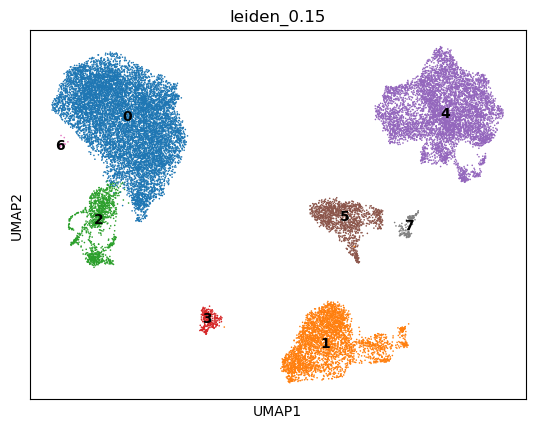

In [4]:
sc.pl.umap(adata, color="leiden_0.15", legend_loc="on data")

In [5]:
sc.tl.leiden(adata, key_added="leiden_0.5", resolution=0.5, flavor="igraph")

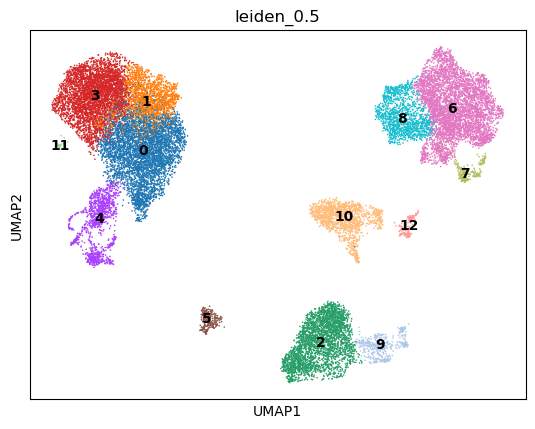

In [6]:
sc.pl.umap(adata, color="leiden_0.5", legend_loc="on data")

In [7]:
marker_genes = {
    "MuSCs & progenitors": ["Pax7", "Myod1"],
    "Mature skeletal muscle": ["Myod1", "Myh1", "Acta1"],
    "FAPS": ["Pdgfra"],
    "Tenocytes": ["Scx"],
    "Endothelial": ["Cdh5"],
    "SMCs & Mesencymal progenitors": ["Cdh5", "Myl9"],
    "Schwann cells": ["Mpz"],
    "Neural/Glial cells": ["Ptn"],
    "Monocytes/Macrophages/Platelets": ["Ptprc", "Ccl6", "Cd74", "C1qa"],
    "Pro-inflammatory macrophages": ["Ptprc", "Ccl6"],
    "Resident macrophages/APCs": ["Ptprc", "Cd74"],
    "Anti-inflammatory macrophages": ["Ptprc", "Cd74", "C1qa"],
    "B, T, & NK cells": ["Ptprc", "Nkg7"]
}
    

MuSCs & progenitors:


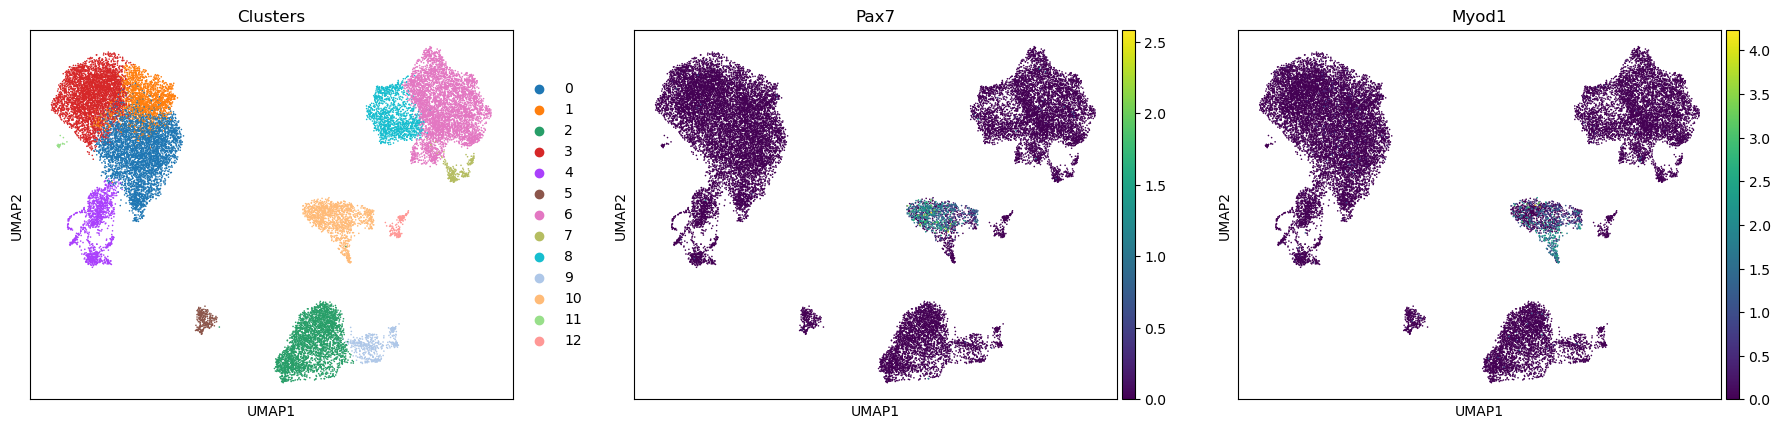

Mature skeletal muscle:


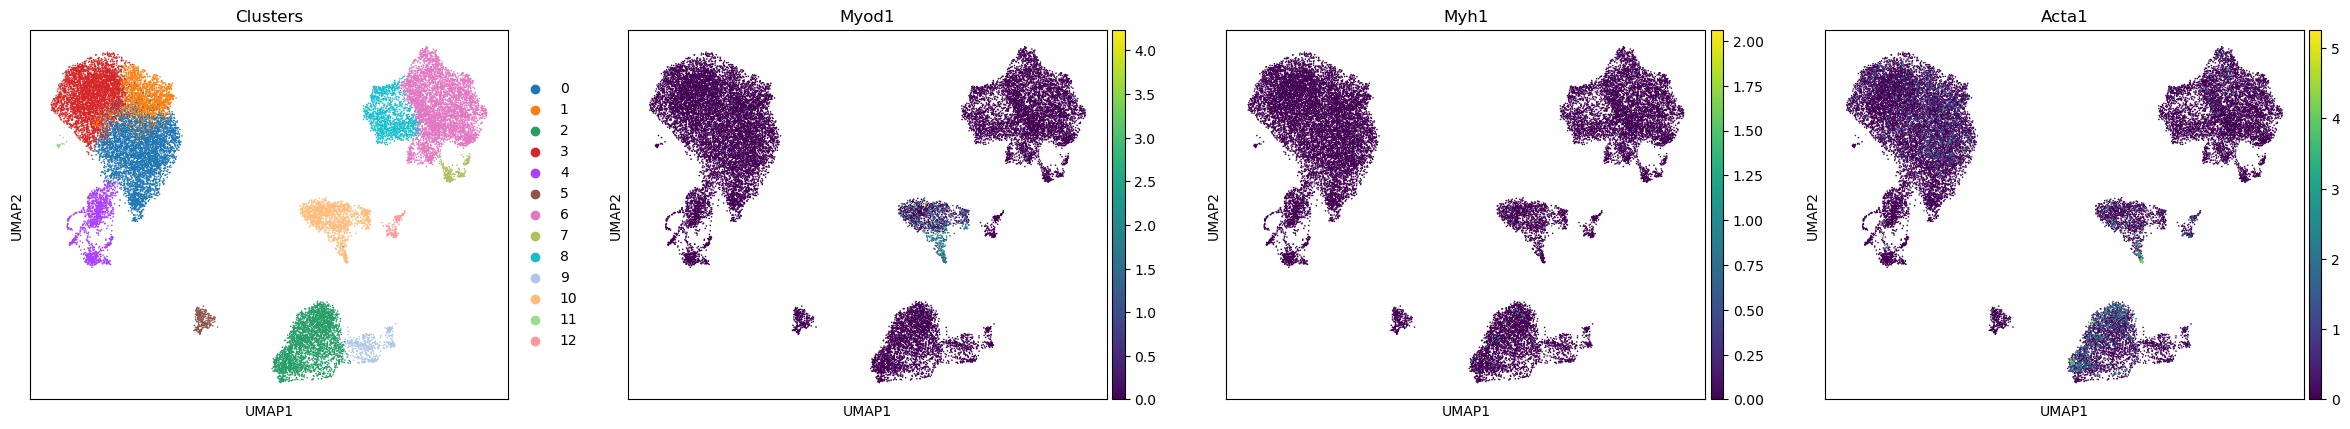

FAPS:


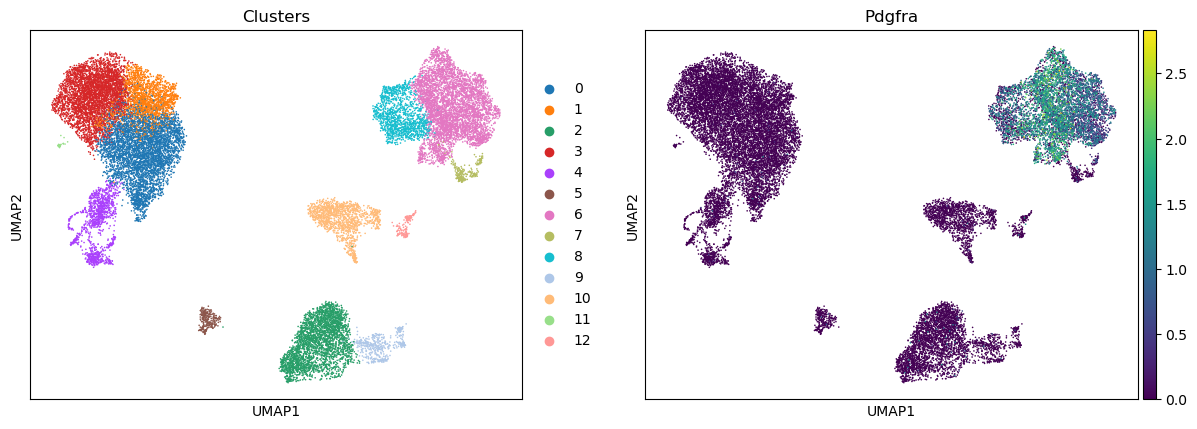

Tenocytes:


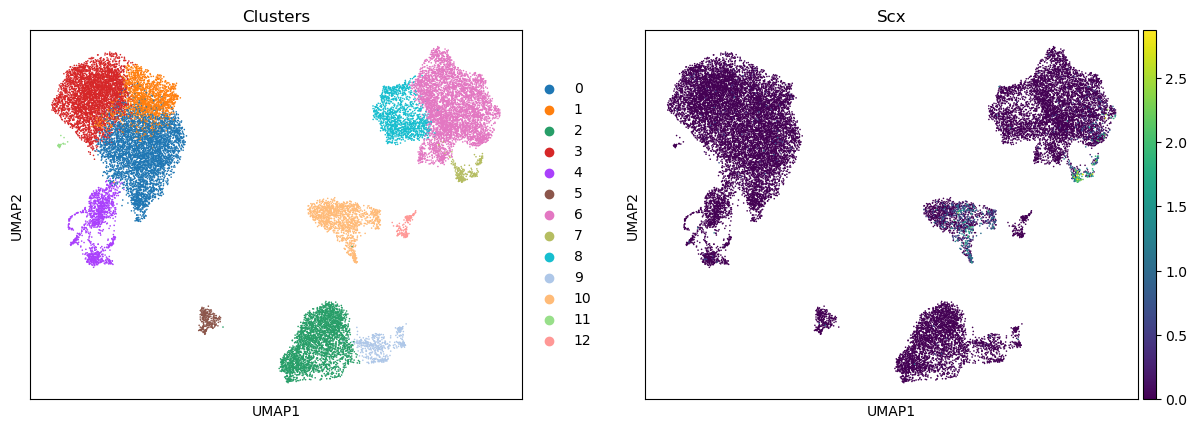

Endothelial:


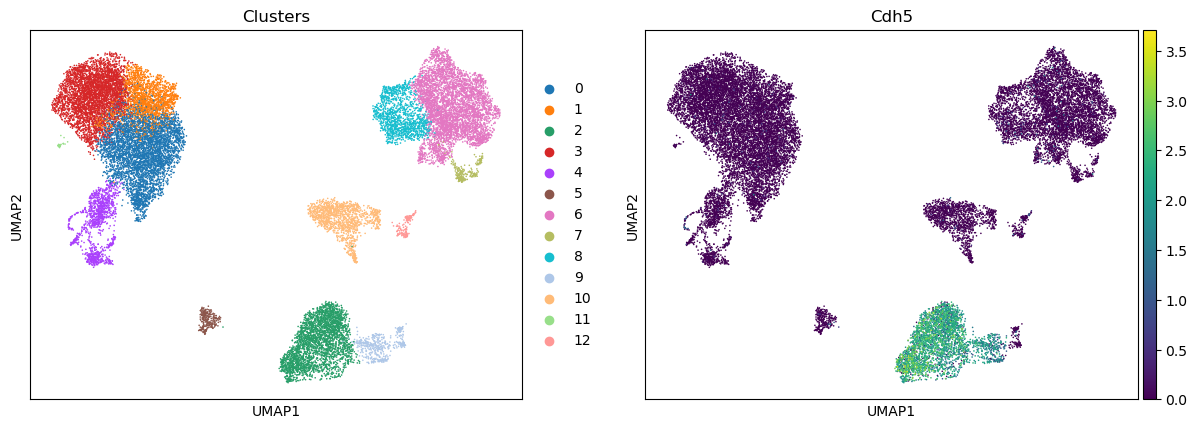

SMCs & Mesencymal progenitors:


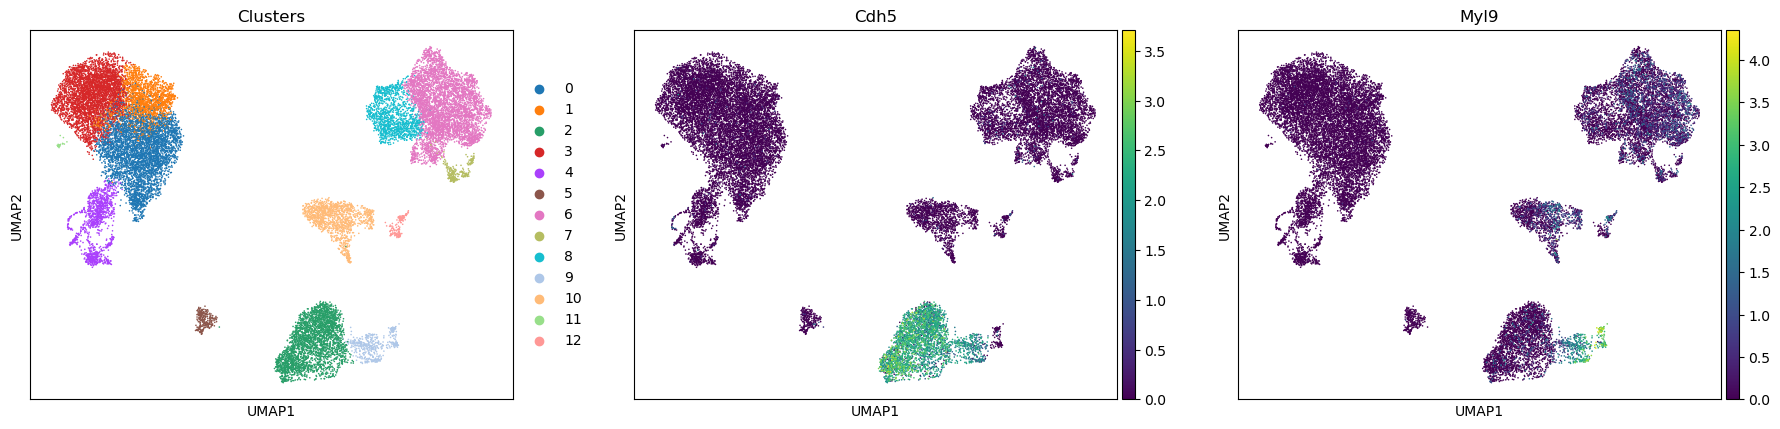

Schwann cells:


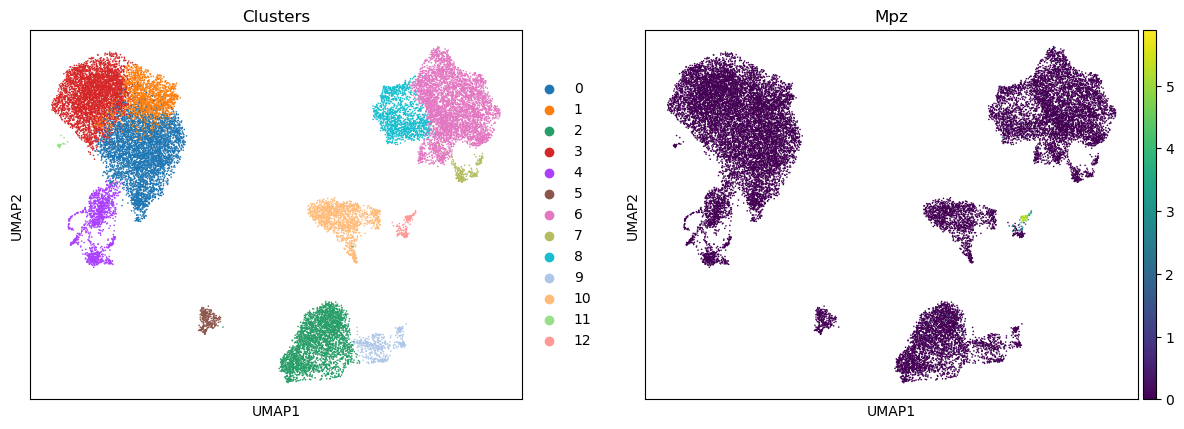

Neural/Glial cells:


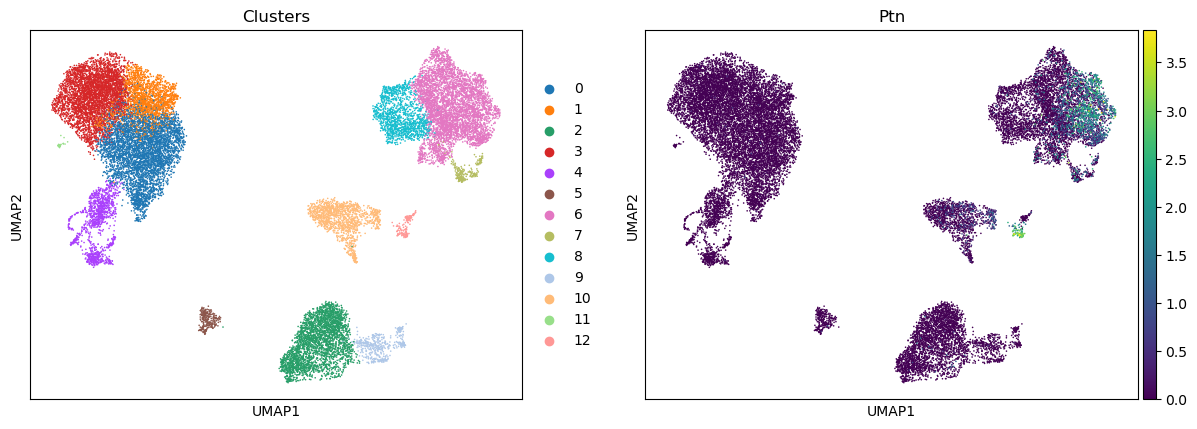

Monocytes/Macrophages/Platelets:


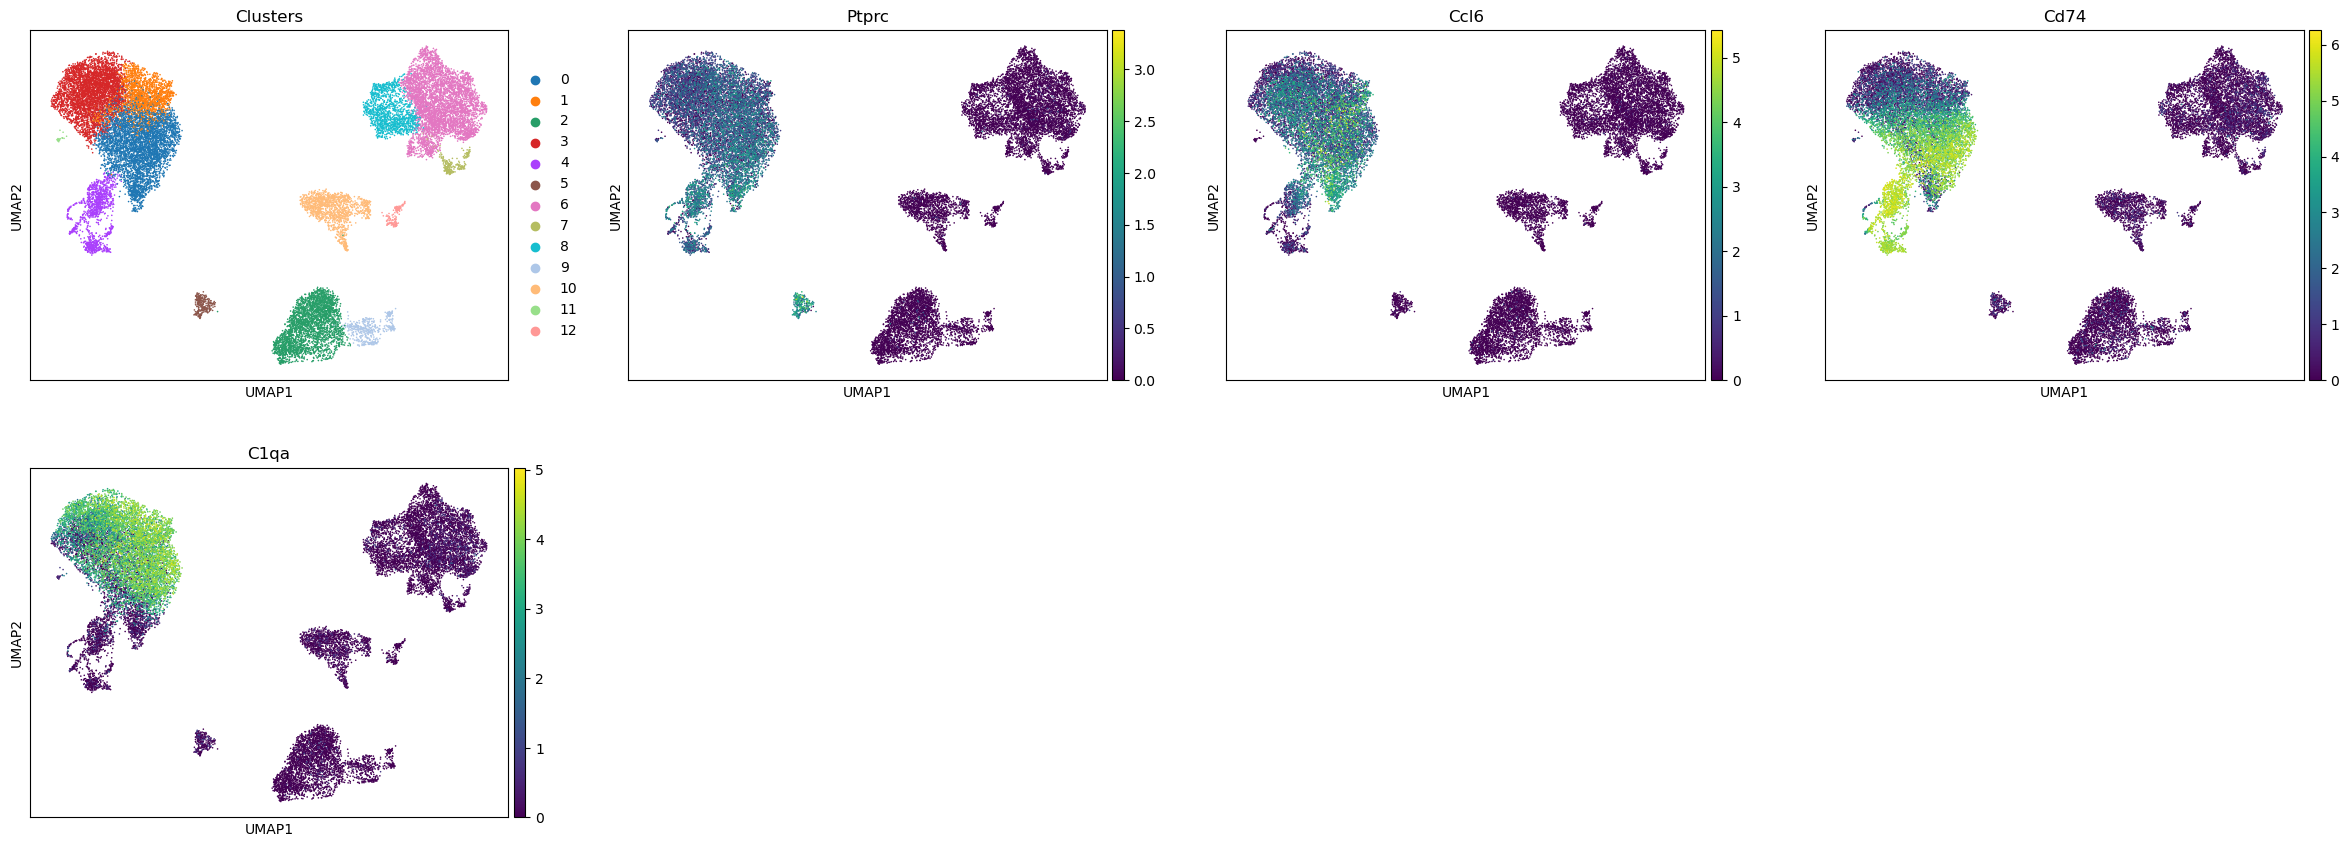

Pro-inflammatory macrophages:


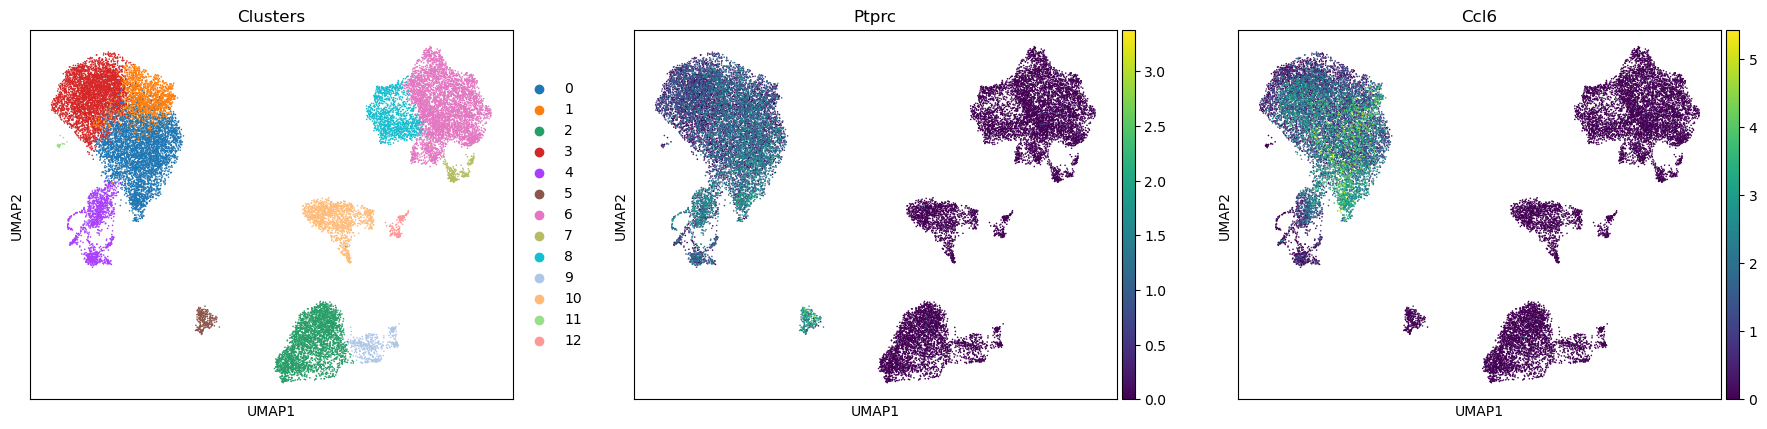

Resident macrophages/APCs:


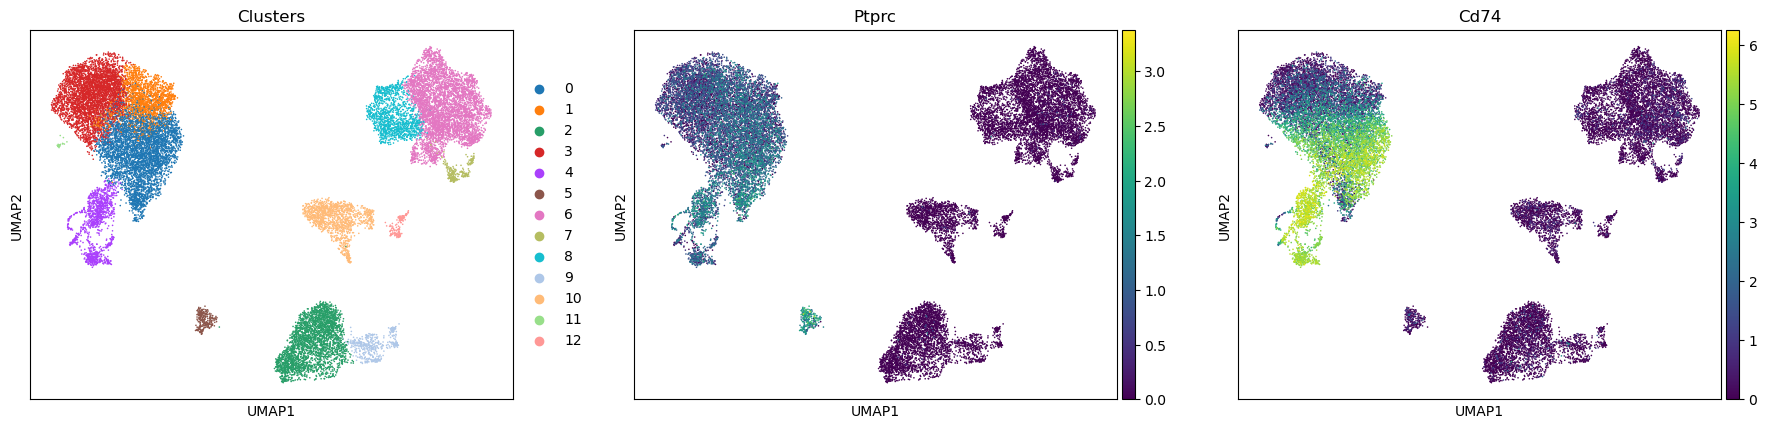

Anti-inflammatory macrophages:


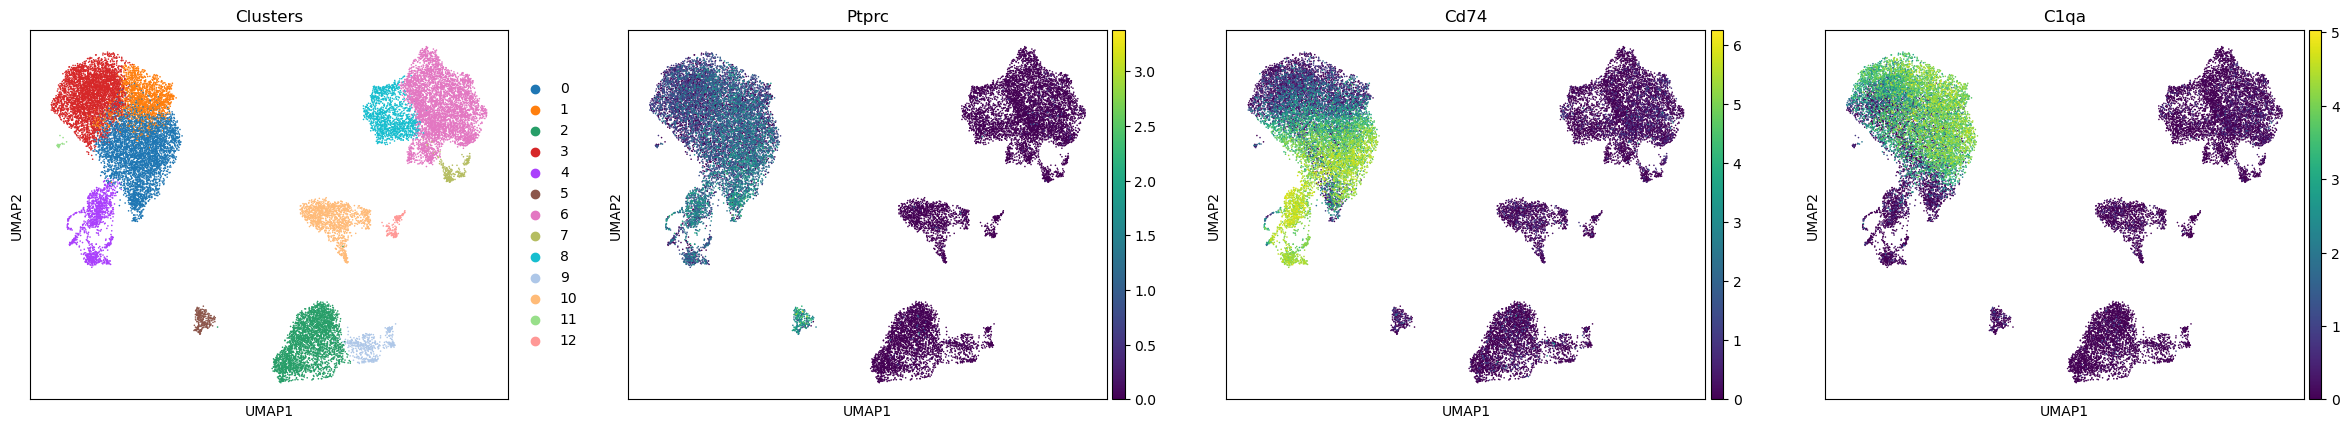

B, T, & NK cells:


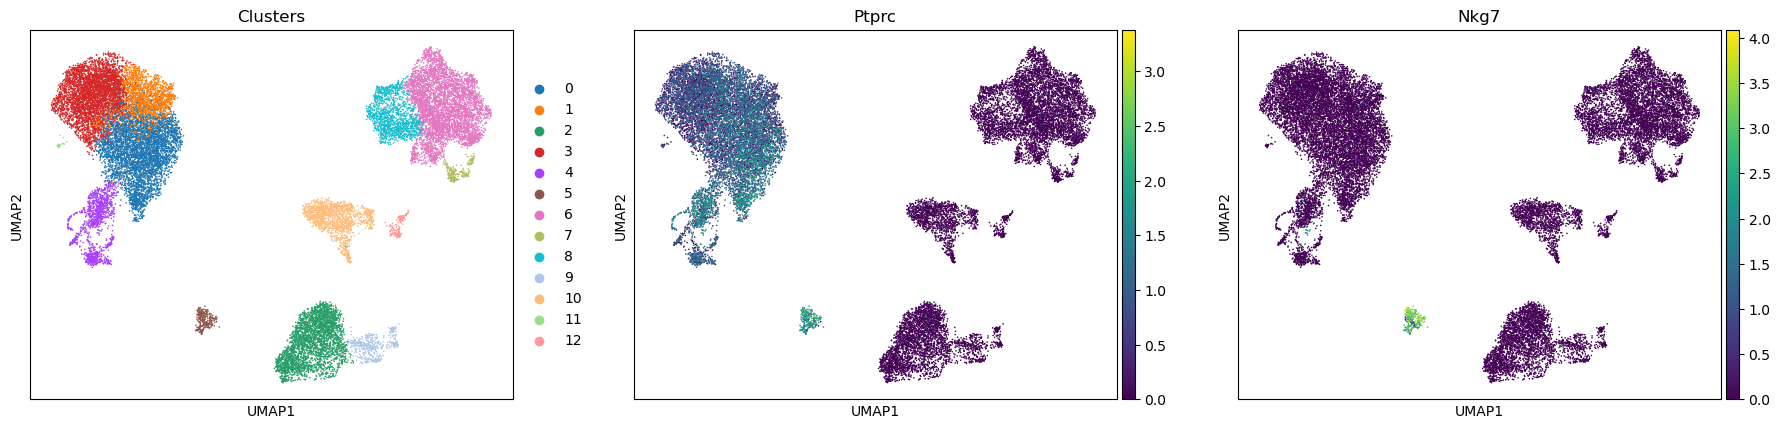

In [8]:
for cell_type, genes in marker_genes.items():
    print(f"{cell_type}:")
    sc.pl.umap(adata, color=["leiden_0.5"] + genes, title=["Clusters"] + genes)

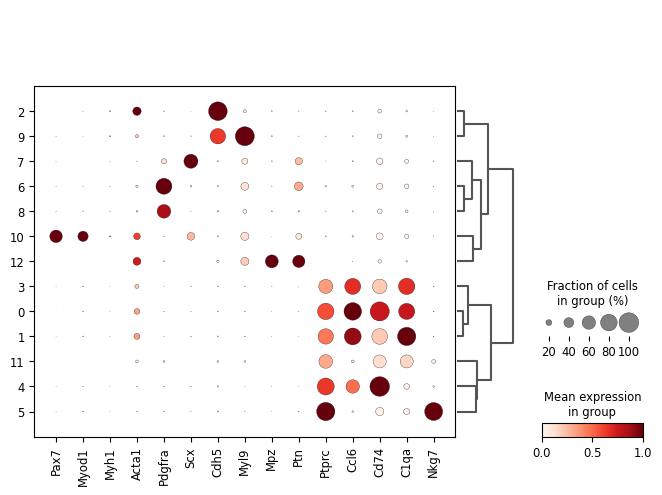

In [9]:
dotplot_genes = ['Pax7', 'Myod1', 'Myh1', 'Acta1','Pdgfra', 'Scx', 'Cdh5', 'Myl9', 
                 'Mpz', 'Ptn', 'Ptprc', 'Ccl6', 'Cd74', 'C1qa', 'Nkg7']
sc.pl.dotplot(adata, var_names=dotplot_genes, groupby="leiden_0.5", standard_scale="var", dendrogram=True)

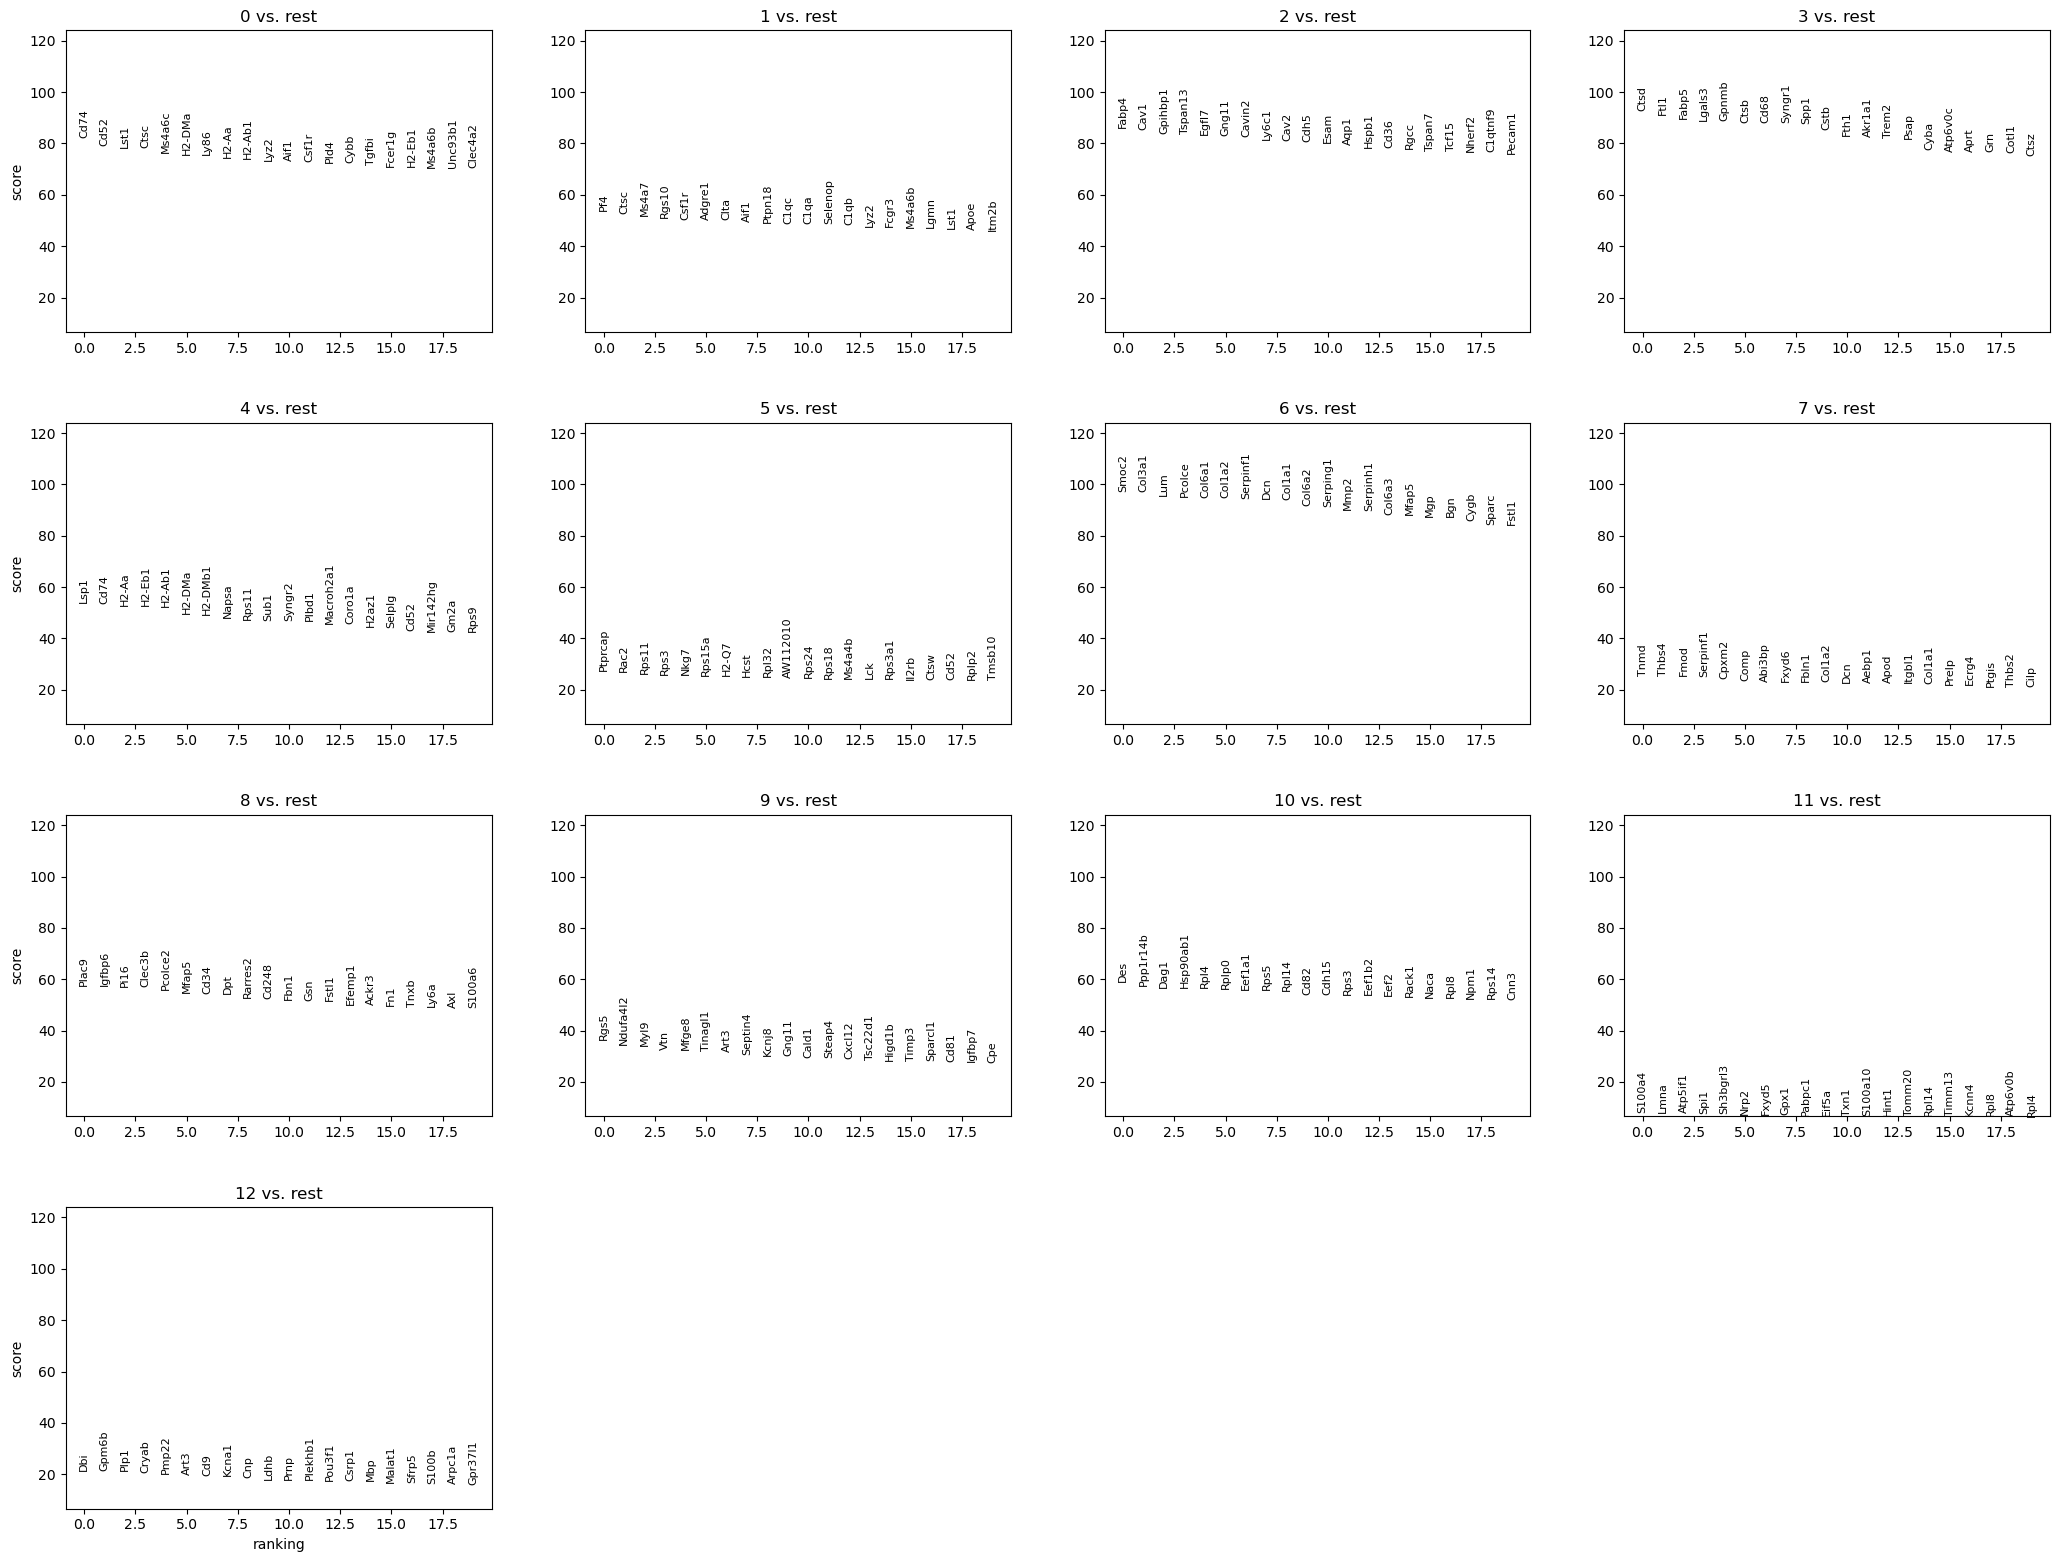

In [10]:
sc.tl.rank_genes_groups(adata, "leiden_0.5", method="wilcoxon")
sc.pl.rank_genes_groups(adata)

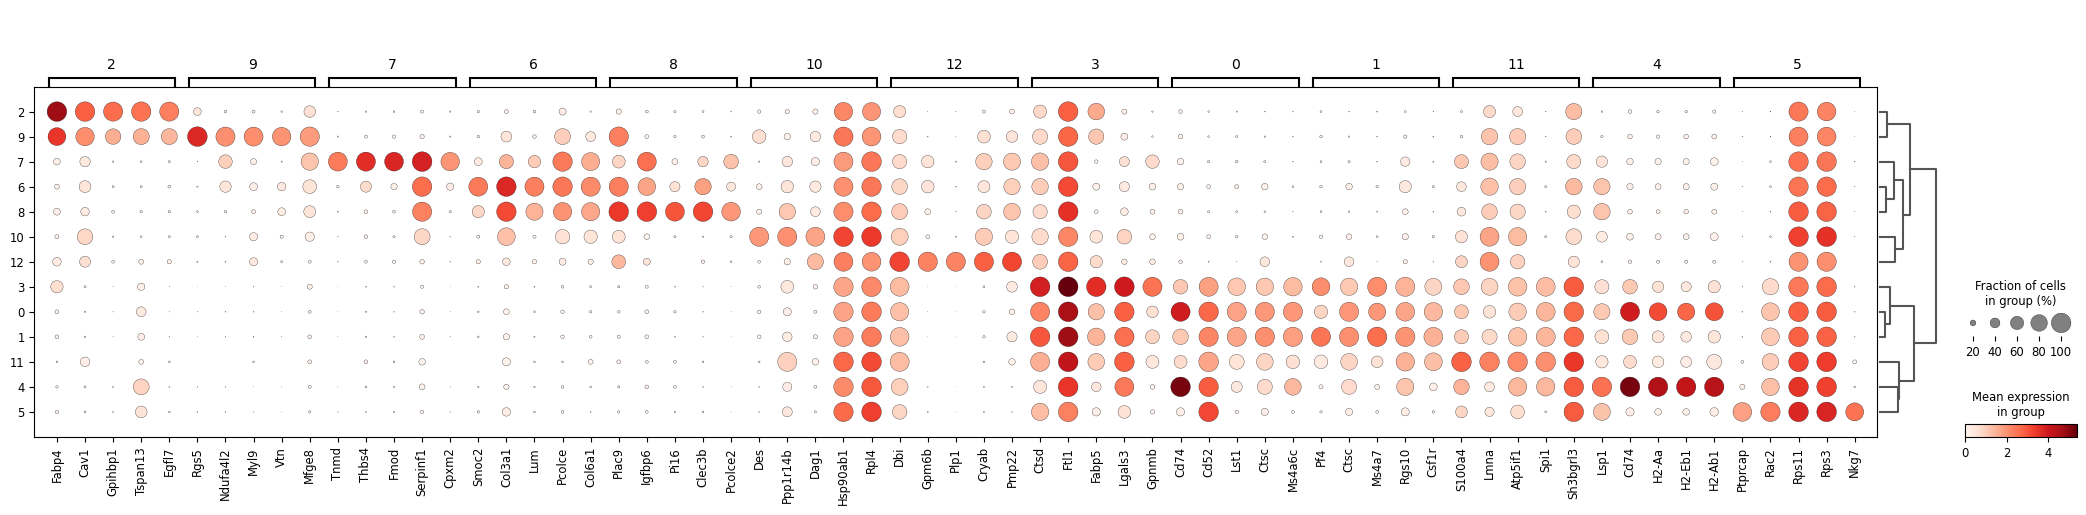

In [11]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_0.5", n_genes=5)

In [12]:
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.2,
                               max_out_group_fraction=0.2)

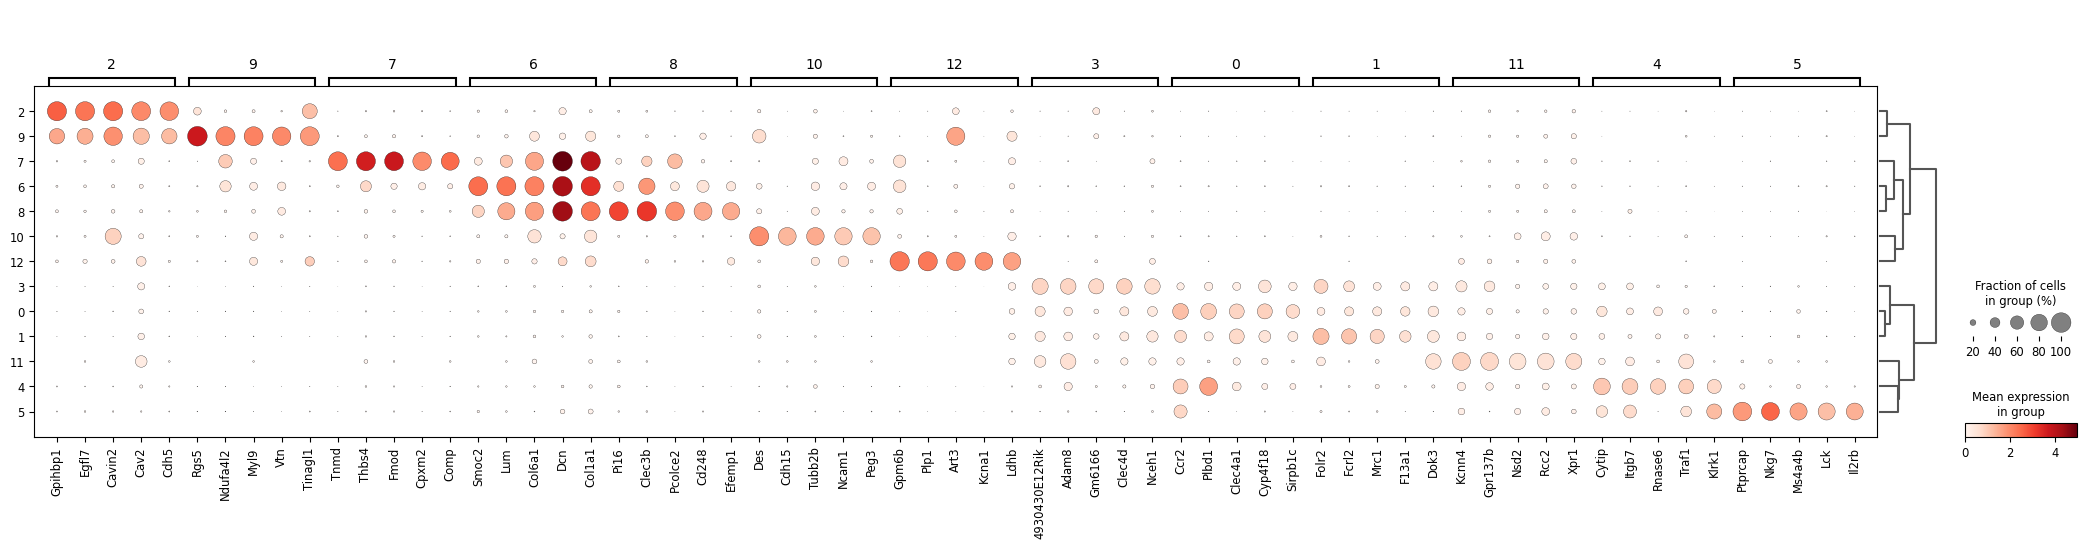

In [13]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_0.5", n_genes=5, key="rank_genes_groups_filtered")

In [14]:
for group in adata.uns["rank_genes_groups_filtered"]["names"].dtype.names:
    genes = adata.uns["rank_genes_groups_filtered"]["names"][group]
    top10 = genes[~pd.isna(genes)][:10]

    print(f"Group {group}:")
    print(", ".join(top10))

Group 0:
Ccr2, Plbd1, Clec4a1, Cyp4f18, Sirpb1c, Gm34276, Napsa, Ighm, Fcgr4, Lpcat2
Group 1:
Folr2, Fcrl2, Mrc1, F13a1, Dok3, Cx3cr1, Cbr2, Clec4n, Ap1b1, Gpr34
Group 2:
Gpihbp1, Egfl7, Cavin2, Cav2, Cdh5, Esam, Aqp1, Tspan7, Tcf15, Nherf2
Group 3:
4930430E12Rik, Adam8, Gm6166, Clec4d, Nceh1, Msr1, Slc37a2, Gm14328, Arl11, Slc27a1
Group 4:
Cytip, Itgb7, Rnase6, Traf1, Klrk1, Klrd1, H2-Oa, Gpr132, Flt3, Avpi1
Group 5:
Ptprcap, Nkg7, Ms4a4b, Lck, Il2rb, Ctsw, Ccl5, Septin1, Ctla2a, Trbc1
Group 6:
Smoc2, Lum, Col6a1, Dcn, Col1a1, Col6a2, Mmp2, Col6a3, Mfap5, Cygb
Group 7:
Tnmd, Thbs4, Fmod, Cpxm2, Comp, Abi3bp, Fbln1, Itgbl1, Prelp, Ecrg4
Group 8:
Pi16, Clec3b, Pcolce2, Cd248, Efemp1, Ackr3, Tnxb, Adamts5, Fndc1, Sema3c
Group 9:
Rgs5, Ndufa4l2, Myl9, Vtn, Tinagl1, Art3, Septin4, Kcnj8, Steap4, Higd1b
Group 10:
Des, Cdh15, Tubb2b, Ncam1, Peg3, Spats2l, Mest, Acta2, Rtn2, Capn6
Group 11:
Kcnn4, Gpr137b, Nsd2, Rcc2, Xpr1, Matk, Nfatc1, Chchd10, Pmf1, Acot7
Group 12:
Gpm6b, Plp1, Art3, Kcna1

In [15]:
adata.obs["cell_type"] = None
adata.obs.loc[adata.obs["leiden_0.5"] == "10", "cell_type"] = "muscle"
adata.obs.loc[adata.obs["leiden_0.5"] == "7", "cell_type"] = "faps"
adata.obs.loc[adata.obs["leiden_0.5"].isin(["6", "8"]), "cell_type"] = "tenocytes"
adata.obs.loc[adata.obs["leiden_0.5"].isin(["0", "1", "3", "4", "11"]), "cell_type"] = "macrophages"

In [16]:
del adata.uns["rank_genes_groups_filtered"]
adata.write("../results/adata/09-annotation.h5ad")